# scVI Embedding Visualization and Biological Structure Analysis

Author: Yuxuan Xu

Description:
This notebook visualizes scVI-derived cell embeddings using UMAP and
evaluates their biological and technical structure through metadata annotations.

The analysis focuses on how well the scVI representation captures:
- Cell type organization
- Developmental (lineage) structure
- Batch effects across samples

Main steps:
- Load AnnData with scVI embeddings
- Compute or reuse UMAP representation
- Visualize UMAP colored by selected metadata features
- Compare biological and technical signals in the embedding space

Goals:
- Assess whether scVI embeddings preserve meaningful biological structure
- Evaluate batch mixing and technical variation
- Support qualitative comparison with other embedding methods

Inputs:
- AnnData object with:
    - scVI embeddings (e.g. `adata.obsm["X_scVI"]` or related key)
    - UMAP coordinates (`adata.obsm["X_umap"]` or derived)
    - Metadata in `adata.obs` (e.g. cell type, batch, developmental stage)

Outputs:
- UMAP plots colored by metadata
- Visual assessment of embedding quality

Notes:
- UMAP is used for visualization only and does not preserve all global structure
- Interpretation should be combined with quantitative analyses where possible

In [1]:
import scanpy as sc
import anndata as ad

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad("/home/ubuntu/sclecture_fm_benchmark/notebooks/explore/data/cxg/retina_ganglion_ex_midget.h5ad")

In [3]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: X_scVI, X_umap)


In [4]:
print(adata.obs.columns.tolist())

['reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sampleid', 'cell_type', 'assay', 'disease', 'sex', 'tissue

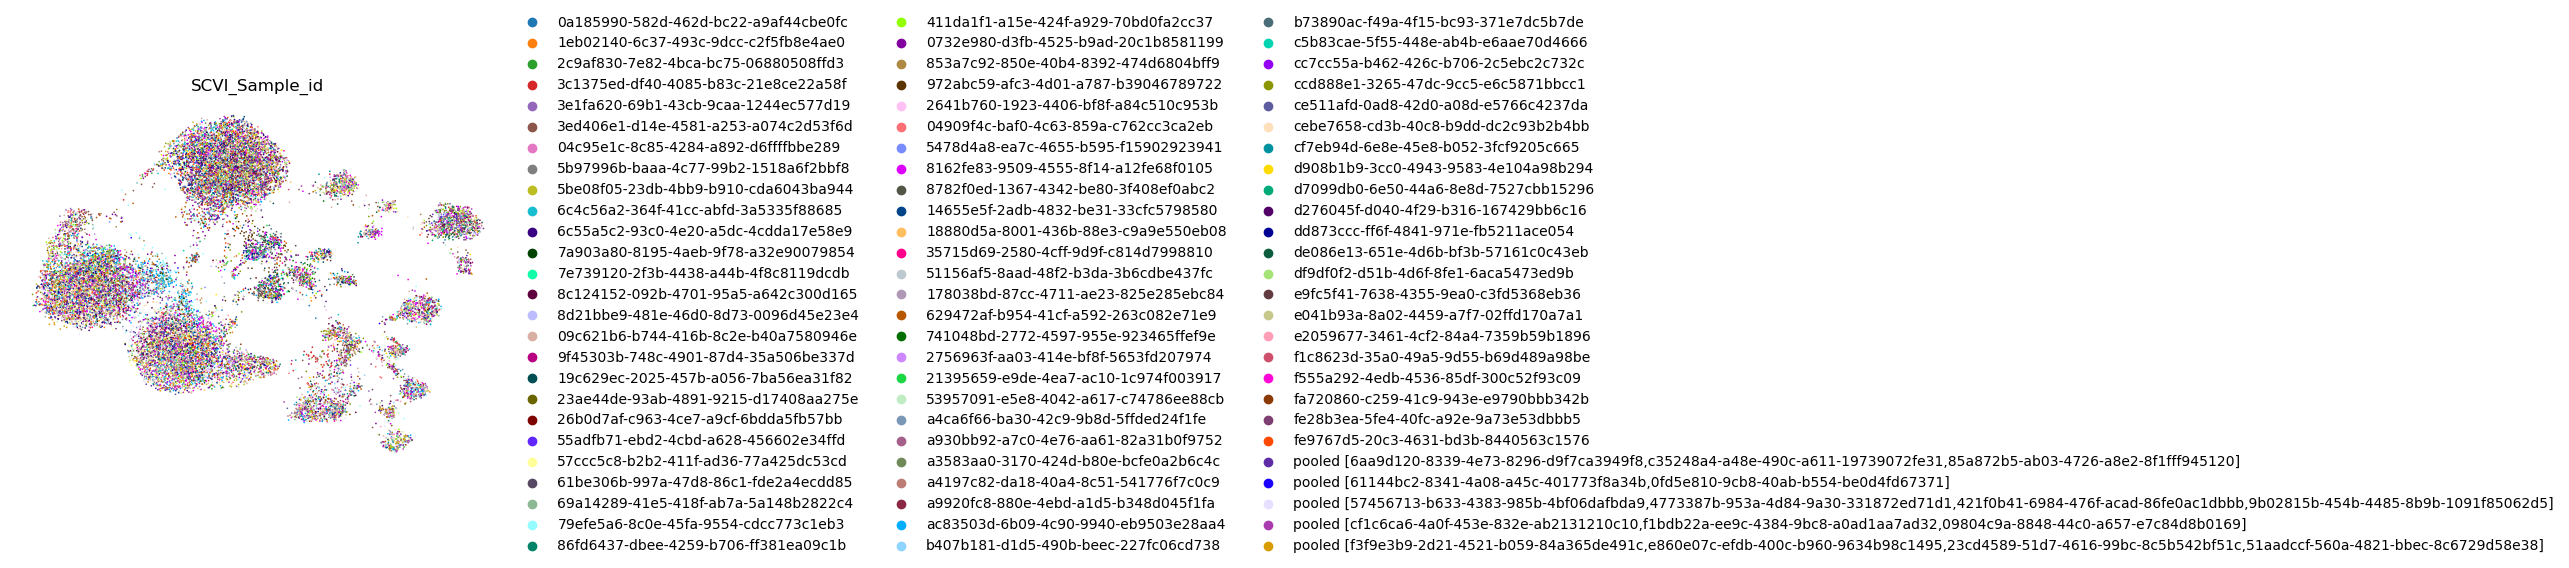

In [5]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap", 
    color=["sample_id"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["SCVI_Sample_id"],
    save = "_scvi_results1.pdf"
)

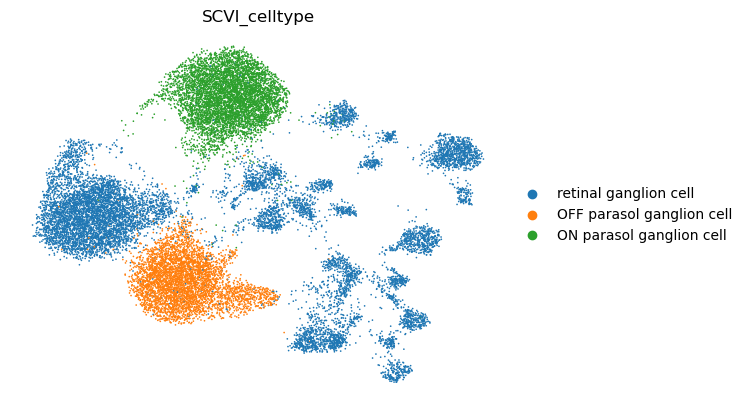

In [6]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap", 
    color=["cell_type"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["SCVI_celltype"],
    save = "_scvI_results1.pdf"
)